In [1]:
import os, sys, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import f1_score
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Input, LSTM, Dense, Dropout, Bidirectional, 
                                     Conv1D, MaxPooling1D, GlobalAveragePooling1D,
                                     BatchNormalization, Activation, Add, 
                                     LayerNormalization, MultiHeadAttention, GlobalMaxPooling1D,
                                     AveragePooling1D, Flatten, Masking, GRU, Concatenate, Lambda, BatchNormalization,)
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.utils import class_weight
from tensorflow.keras.metrics import Precision, Recall
from sklearn.metrics import f1_score, balanced_accuracy_score
from tensorflow.keras.callbacks import Callback

In [2]:
# This block is used to make the results more reproducible.

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

for gpu in tf.config.list_physical_devices("GPU"):
    tf.config.experimental.enable_op_determinism()
    tf.config.experimental.set_memory_growth(gpu, True)

tf.get_logger().setLevel("ERROR")

In [3]:
sys.path.append(os.getcwd().replace("\\", "/"))

from Augmentation import (Noise_aug, filter_short_sequences, split_long_seq, GP_aug,
prepare_sequence, AvgPair_segments, ChannelDrop_aug, TimeShift_aug, TimeMask_aug, cap_long_seq,
Noise_aug_with_shift, Scale_aug)

In [4]:
dir = f'{os.getcwd().replace("\\", "/")}/Data/Porcessed Data/CNN_split'
df = pd.read_csv(f"{dir}/train_df.csv")
df_valid = pd.read_csv(f"{dir}/test_df.csv")
df_test = pd.read_csv(f"{dir}/CNN_test.csv")
df.head()

,object_id,Time (MJD),Filter_z_flux,Filter_z_flux_err,Filter_r_flux,Filter_r_flux_err,Filter_y_flux,Filter_y_flux_err,Filter_i_flux,Filter_i_flux_err,Filter_g_flux,Filter_g_flux_err,Filter_u_flux,Filter_u_flux_err,SpecType
0,Dornhoth_fervain_onodrim,63314.4662,-1.895487,0.425312,0.000000,0.000000,-1.601633,1.191244,0.000000,0.000000,0.000000,0.000000,0.0,0.0,AGN
1,Dornhoth_fervain_onodrim,63327.6691,-1.811662,0.462278,0.000000,0.000000,0.000000,0.000000,-1.709337,0.389580,0.000000,0.000000,0.0,0.0,AGN
2,Dornhoth_fervain_onodrim,63340.8720,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-2.495971,0.403594,0.000000,0.000000,0.0,0.0,AGN
3,Dornhoth_fervain_onodrim,63380.4806,0.000000,0.000000,-1.328391,0.225768,0.000000,0.000000,0.000000,0.000000,-1.253124,0.255106,0.0,0.0,AGN
4,Dornhoth_fervain_onodrim,63420.0891,0.000000,0.000000,-1.396016,0.576872,0.000000,0.000000,0.000000,0.000000,-0.693107,0.241171,0.0,0.0,AGN


In [5]:
# Drop unnecessary columns and apply binary encoding to the `SpecType` column.
A_lambda = [c for c in df.columns if "A_lambda" in c]
dropped =["split","EBV","Z"] + A_lambda
df["target"] = (df["SpecType"] != "AGN").astype(int)
df_valid["target"] = (df_valid["SpecType"] != "AGN").astype(int)
df.drop(columns=["SpecType"], inplace=True), df_test.drop(columns=dropped, inplace=True), df_valid.drop(columns=["SpecType"], inplace=True)
cols = df.drop(columns=["object_id", "Time (MJD)","target"]).columns.tolist()
target = "target"

In [6]:

list_1 = [x for x in range(10)]
print(list_1)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [7]:
df.describe()

,Time (MJD),Filter_z_flux,Filter_z_flux_err,Filter_r_flux,Filter_r_flux_err,Filter_y_flux,Filter_y_flux_err,Filter_i_flux,Filter_i_flux_err,Filter_g_flux,Filter_g_flux_err,Filter_u_flux,Filter_u_flux_err,target
count,231196.000000,231196.000000,231196.000000,231196.000000,231196.000000,231196.000000,231196.000000,231196.000000,231196.000000,231196.000000,231196.000000,231196.000000,231196.000000,231196.000000
mean,62912.220715,0.227919,0.192453,0.259344,0.087707,0.147404,0.317267,0.266568,0.133547,0.097125,0.029592,0.059831,0.065664,0.448386
std,908.440751,1.417704,0.324072,1.550385,0.148462,1.321489,0.614922,1.507618,0.215179,1.076593,0.088921,1.063625,0.196766,0.497330
min,60979.598400,-20.403083,0.000000,-19.101684,0.000000,-15.165649,0.000000,-20.979804,0.000000,-28.582649,0.000000,-46.764388,0.000000,0.000000
25%,62199.276300,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,62967.419900,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,63599.091025,0.000000,0.409453,0.000000,0.164983,0.000000,0.000000,0.000000,0.258408,0.000000,0.000000,0.000000,0.000000,1.000000
max,64632.737000,63.939762,7.811669,65.606458,4.914303,106.839852,8.538723,56.818243,7.395473,98.624511,5.359896,133.079466,18.236183,1.000000


In [8]:
# Cap the length of the sequences and remove short sequences
df = cap_long_seq(df, "object_id", max_len=100)
df_valid = cap_long_seq(df_valid, "object_id", max_len=100)
df = filter_short_sequences(df, "object_id", min_len=30)
print(df['object_id'].value_counts())

object_id
Dornhoth_anwar_melethron     100
Dornhoth_archam_grond        100
Dornhoth_certh_iaun          100
Dornhoth_galadh_ylf          100
Dornhoth_gwend_nagol         100
                            ... 
fervain_rochben_Rochirrim     31
firion_lorn_certh             31
fast_celeb_bregedur           30
lebenedh_imrad_adab           30
yll_tamin_fern                30
Name: count, Length: 2409, dtype: int64


In [9]:
round(pd.DataFrame(df[target].value_counts())/df.shape[0],2)

,count
target,
0,0.57
1,0.43


In [10]:
# convert DF → padded sequences
X_train, y_train, X_final = prepare_sequence(df, df_test, "object_id", cols, target)
X_valid, y_valid, _ = prepare_sequence(df_valid, df_test, "object_id", cols, target)

# Add some random noise to the data
X_noise, y_noise = Noise_aug(X_train, y_train, noise_level=0.07, n_aug=1)

# GP: add gaussian noise with the mean and the variance be per light curve per channel
# X_syn, y_syn = GP_aug(X_train, y_train, n_aug=1)

# Flux Shift
X_flux_shi, y_flux_shi = Noise_aug_with_shift(X_train, y_train, n_aug=1, shift_range=(-5, 5))

# Scale by a constant
X_scal, y_scal = Scale_aug(X_train, y_train, scale_range=(0.5, 2), n_aug=1)

# replacing each point with the average of the before and after point
X_avg, y_avg = AvgPair_segments(X_train, y_train, n_aug=1)

# Time shift, the most important feature augmentation
X_shi, y_shi = TimeShift_aug(X_train, y_train, n_aug=1)

# Time mask
X_mas, y_mas = TimeMask_aug(X_train, y_train, n_aug=1)

In [12]:
# Create an augmented version of the validation data to test the model
X_noise_t, y_noise_t = Noise_aug(X_valid, y_valid, noise_level=0.1, n_aug=1)
X_syn_t, y_syn_t = TimeShift_aug(X_valid, y_valid, n_aug=1)
X_avg_t, y_avg_t = AvgPair_segments(X_valid, y_valid, n_aug=1)

X_valid_aug = np.concatenate([X_valid,X_noise_t,X_avg_t], axis=0)
y_valid_aug = np.concatenate([y_valid,y_noise_t,y_avg_t], axis=0)

perm = np.random.permutation(len(y_valid_aug))
X_valid_aug = X_valid_aug[perm]
y_valid_aug = y_valid_aug[perm]

print(X_valid_aug.shape)
print(y_valid_aug.shape)

(1827, 100, 12)
(1827,)


In [13]:
# Compine all the data
X_combined = np.concatenate([X_train, X_noise, X_flux_shi, X_scal, X_avg, X_shi, X_mas], axis=0)
y_combined = np.concatenate([y_train, y_noise, y_flux_shi, y_scal, y_avg, y_shi, y_mas], axis=0)

perm = np.random.permutation(len(y_combined))
X_combined = X_combined[perm]
y_combined = y_combined[perm]

print(X_combined.shape)
print(y_combined.shape)

(16863, 100, 12)
(16863,)


In [14]:
def tcn_block(x, filters, kernel_size, dilation_rate, dropout):
    prev = x

    x = Conv1D(
        filters,
        kernel_size,
        padding="causal",
        dilation_rate=dilation_rate, name=f"Conv_A1_{dilation_rate}"
    )(x)
    x = BatchNormalization(name=f"Normalize_A1_{dilation_rate}")(x)
    x = Activation("relu", name=f"Acti_A1_{dilation_rate}")(x)
    x = Dropout(dropout, name=f"Drop_A1_{dilation_rate}")(x)

    x = Conv1D(
        filters,
        kernel_size,
        padding="causal",
        dilation_rate=dilation_rate, name=f"Conv_B1_{dilation_rate}"
    )(x)
    x = BatchNormalization(name=f"Normalize_B1_{dilation_rate}")(x)
    x = Activation("relu", name=f"Acti_B1_{dilation_rate}")(x)

    if prev.shape[-1] != filters:
        prev = Conv1D(filters, 1, padding="same", name=f"Conv_prev1_{dilation_rate}")(prev)

    return Add()([prev, x])

In [15]:
def modelS():
    inputs = Input(
        shape=(X_train.shape[1], X_train.shape[2]),
        name="Input_1"
    )

    x = inputs

    for d in [1, 2, 4]:
        x = tcn_block(
            x,
            filters=64,
            kernel_size=3,
            dilation_rate=d,
            dropout=0.2
        )

    x = GlobalAveragePooling1D()(x)

    x = Dense(128, activation="relu", name="Dense_A1")(x)
    x = Dropout(0.3)(x)

    x = Dense(32, activation="relu", name="Dense_B1")(x)
    x = Dropout(0.3)(x)

    outputs = Dense(1, activation="sigmoid", name="Dense_C1")(x)

    return Model(inputs, outputs)

In [16]:
# Create class weights to help the model handle data imbalance
classes = np.unique(y_combined)
weights = class_weight.compute_class_weight(class_weight='balanced', classes=classes, y=y_combined)
class_weights = dict(zip(classes, weights))

In [17]:
# Model training with early stopping
early_stop = EarlyStopping(
        monitor="val_aucpr",
        patience=20,
        verbose=1,
        restore_best_weights=True,
)

model = modelS()

model.compile(
    optimizer=Adam(
        learning_rate=0.0001,
        gradient_accumulation_steps=8),
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.AUC(curve="PR", name="aucpr")]
)

history = model.fit(
    X_combined,
    y_combined,
    epochs=100,
    batch_size=128,
    validation_data=(X_valid, y_valid),
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 25s 96ms/step - aucpr: 0.4246 - loss: 0.7602 - val_aucpr: 0.5950 - val_loss: 0.6776
Epoch 2/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 12s 90ms/step - aucpr: 0.4459 - loss: 0.7213 - val_aucpr: 0.7504 - val_loss: 0.6647
Epoch 3/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 13s 99ms/step - aucpr: 0.4665 - loss: 0.7058 - val_aucpr: 0.8529 - val_loss: 0.6498
Epoch 4/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 12s 91ms/step - aucpr: 0.5119 - loss: 0.6792 - val_aucpr: 0.8906 - val_loss: 0.6277
Epoch 5/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 13s 94ms/step - aucpr: 0.5941 - loss: 0.6497 - val_aucpr: 0.9124 - val_loss: 0.5944
Epoch 6/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 12s 93ms/step - aucpr: 0.6670 - loss: 0.6127 - val_aucpr: 0.9171 - val_loss: 0.5471
Epoch 7/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 13s 98ms/step - aucpr: 0.7422 - loss: 0.5636 - val_aucpr: 0.9259 - val_loss: 0.4773
Epoch 8/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 12s 89ms/step - aucpr: 0.8081 - loss: 0.5005 - val_aucpr: 0.9351 - val_loss: 0.4167


min val_loss 0.153


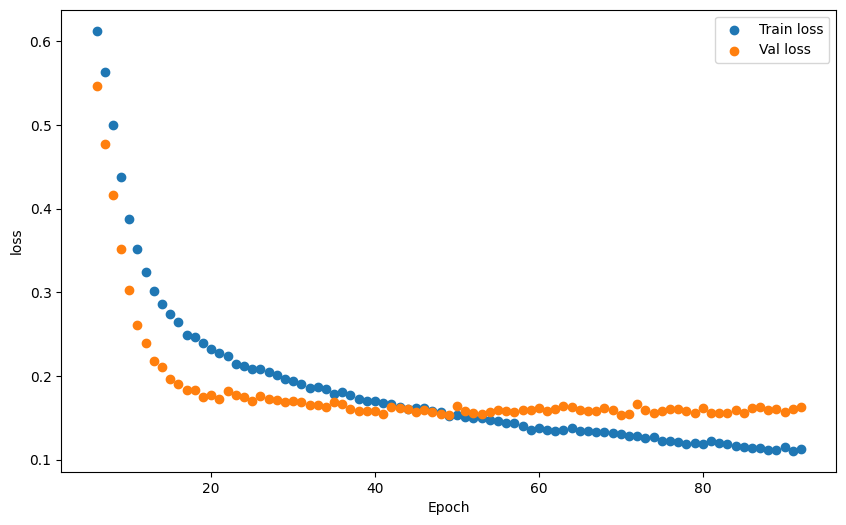

In [18]:
# Plot training and validation loss versus epochs
epochs = range(1, len(history.history["loss"]) + 1)
min_loss = min(history.history["val_loss"])
print(f"min val_loss {round(min_loss,3)}")
plt.figure(figsize=(10, 6))
plt.scatter(epochs[5:], history.history["loss"][5:], label="Train loss")
plt.scatter(epochs[5:], history.history["val_loss"][5:], label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

max AUCPR 0.982


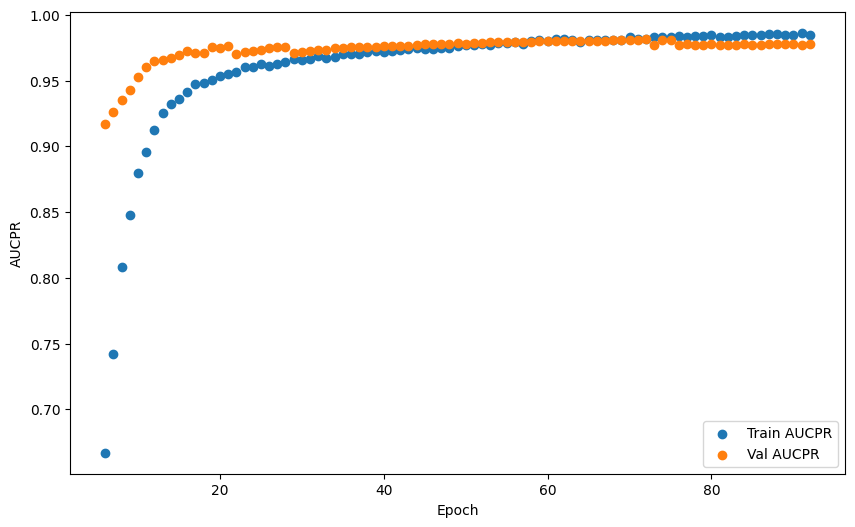

In [19]:
# Plot training and validation AUCPR versus epochs
epochs = range(1, len(history.history["aucpr"]) + 1)
max_auc = max(history.history["val_aucpr"])
print(f"max AUCPR {round(max_auc,3)}")
plt.figure(figsize=(10, 6))
plt.scatter(epochs[5:], history.history["aucpr"][5:], label="Train AUCPR")
plt.scatter(epochs[5:], history.history["val_aucpr"][5:], label="Val AUCPR")
plt.xlabel("Epoch")
plt.ylabel("AUCPR")
plt.legend()
plt.show()

In [20]:
y_pred_prob = model.predict(X_train)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
f1 = f1_score(y_train, y_pred)
print("Validation_aug F1 score:", round(f1,4))

76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
Validation_aug F1 score: 0.9678


In [21]:
y_pred_prob = model.predict(X_combined)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
f1 = f1_score(y_combined, y_pred)
print("Validation_aug F1 score:", round(f1,4))

527/527 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step
Validation_aug F1 score: 0.9418


In [22]:
y_pred_prob = model.predict(X_valid_aug)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
f1 = f1_score(y_valid_aug, y_pred)
print("Validation_aug F1 score:", round(f1,4))

58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
Validation_aug F1 score: 0.921


In [23]:
y_pred_prob = model.predict(X_valid)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
f1 = f1_score(y_valid, y_pred)
print("Validation F1 score:", round(f1,4))

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Validation F1 score: 0.9387


In [24]:
# Iterate over thresholds to find the best F1 score
scores = []
max_f1 = 0
best_thr = 0
y_pred = model.predict(X_valid,verbose=0)
for t in np.linspace(0.05, 0.95, 201):
    f1 = f1_score(y_valid, y_pred > t)
    scores.append(f"thr {t:.3f}: f1 {f1:.3f}")
    if f1 > max_f1:
        max_f1 = f1
        best_thr = t

print(f"Best F1: {max_f1:.3f} at threshold {best_thr:.3f}")

Best F1: 0.960 at threshold 0.932


Best F1: 0.962 at threshold 0.878

In [25]:
model.save(f"{os.getcwd().replace("\\", "/")}/models/model_1_v3.keras")